# HW10: Convolutional NN's, and back to predictive modeling basics

## instructions

our course will be using an automatic grading system. <br>
after each question there will appear a code block with some prepared code to add your answer to a dictionary that will be sent to the course server for grading. <br>
please do not edit any code other than in placeholders marked `#### your code here ####` <br>
__don't forget to run the code block after you write your answer.__


you can add code blocks wherever you want in order to interact with datasets and play with your own code. <br>
in the next code block plase fill in your id number and email account in the appropriate placees. <br>
and __don't forget to run the block!__

In [63]:
ans = {}
ans['HW'] = 'HW10'
ans['id_number'] = 'ID_REMOVED'

#### Q1)
We described a CNN as a sequence of layers, consisting of convolution layers and max-pooling layers (and possibly others like dropout), and at the end a flattening and fully connected layer. 
Assume we have two versions of the same image, call them $A$ and $B$ with a shift between them of a few pixels: $A(i,j) = B(i+k_1, j+k_2),\; \forall i,j$ (with appropriate "neutral" padding at the edges to make the images of the same size, which does not have features that correspond to convolution filters). 
Suppose we run both through the same network (after training) that contains several pairs of convlution+max pooling layers, and takes this to extreme by ending up with a large number $K$ of tiny $1\times 1$ images. What is likely to be true of these images?

1. The $K$ values will be the same for $A,B$, but not in the same order
2. Because the images are shifted, the eventual tiny convolution images will be different
3. The $K$ values will likely be identical for both initial images
4. The eventual images will be different, even if there is no shift ($k_1=k_2=0$)

In [64]:
ans['Q1'] = 2

#### Q2)
In the CNN we saw in class, after each convolution layer there was a non-linearity "layer" (meaning a non-linear transformation was applied to the resulting convolution images before the next layer). In this example it was relu:
$$ relu(x) = x^+ = max(x,0).$$
Assume the following: we have a grey-level image (white=0, black=255) with a black vertical line on a white background, and we apply to it a filter that searches for a vertical line (similar to what  we showed in class):
$$ f = \left( \begin{array}{ccc} -0.5 & 1 & -0.5 \\ -0.5 & 1 & -0.5 \\ -0.5 & 1 & -0.5 \end{array} \right).$$
We then do a relu transformation on the resulting image, then max-pooling, and another identical filter for a vertical line. Will the resulting image have a dark vertical line in it?  

1. Yes, because the non-linearity is monotone and maintains the dark line
2. No, because the non-linearity changes the meaning of the image
3. Yes, because this filter creates convolution images with dark lines regardless of what is in the original image
4. No, because this filter destroys the lines in the original image

In [65]:
ans['Q2'] = 1

#### Q3)
Which of the following **does not** add flexibility to the model?

1. Adding variables to an OLS model
2. Increasing the depth of a tree model
3. Adding more trees (iterations) to a boosting model
4. Adding more trees (iterations) to a Random Forest model

In [66]:
ans['Q3'] = 4

#### Q4)
Assume that instead of dividing our data into training and test set as we did in class, we divide it into three parts: 
* train (say 60%)
* validation (say 20%)
* test (20%)
We train several different models on the training set, choose between them based on validation set performance, and apply the winner to the test set. The problem can be regression or classification, and the error measure can be squared loss, misclassification erorr, or any other relevant measure. 
Denote the prediction error on train by $e_{tr}$, and respectively $e_{va}$ and $e_{te}$. What is the typical order between the errors of the chosen model on the different sets ($\approx$ means approximately equal or typically similar):

1. $e_{tr} \leq e_{va} \leq e_{te}$
2. $e_{tr} \approx e_{va} \leq e_{te}$
3. $e_{tr} \leq e_{va} \approx e_{te}$
4. $e_{tr} \approx e_{va} \approx e_{te}$


In [67]:
ans['Q4'] = 3

# CSD 7: Deep Learning for Image Classification

0. For this Case Study assignment you should have in your current folder the ebay_boys_girls_shirts folder, holding the four CSV files describing the train and test shirts images, and the boys and girls images folders. This is what we did in CSD 1, **if you already have the data in your current folder you don't need to run this again!**:

In [7]:
import requests
import tarfile

url = "http://www.tau.ac.il/~saharon/DScourse/ebay_boys_girls_shirts.tar.gz"
r = requests.get(url)

with open("ebay_boys_girls_shirts.tar", "wb") as file:
    file.write(r.content)

with tarfile.open("ebay_boys_girls_shirts.tar") as tar:
    tar.extractall('.')

1. In this Case Study assignment we again try to classify an unseen shirt image as being of "boys" or of "girls". Yet this time we will be using heavier machinery: Deep Learning. Specifically we're going to get good results using Convolutional Neural Networks.

    But first, load all matrices with the help of the functions composed so far:

In [8]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform, color, img_as_ubyte

%matplotlib inline

def get_file_list(df, folder, n_sample = None, seed = None):
    if n_sample is None:
        file_ids_list = df.file_id.values
    else:
        file_ids_list = df.sample(n = n_sample, random_state = seed).file_id.values
    files_list = [folder + '/' + str(file_id) + '.jpg' for file_id in file_ids_list]
    return files_list

def read_image_and_resize(f, w = 100, h = 100):
    img = plt.imread(f)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        img = transform.resize(img, (w, h), mode='constant')
        img = img_as_ubyte(img)
    img = color.gray2rgb(img)
    img = img[np.newaxis, :, :, :3]
    if img.shape != (1, 100, 100, 3):
        raise ValueError(f + str(img.shape))
    return img

def read_images_4d_array(files_list):
    images_list = [read_image_and_resize(file) for file in files_list]
    images_array = np.concatenate(images_list)
    return images_array

def get_images_matrix(csv_file, folder, n = None, seed = 1976):
    df = pd.read_csv(csv_file)
    files_list = get_file_list(df, folder, n, seed)
    images = read_images_4d_array(files_list)
    return images, files_list

def get_all_pixels(x):
    return x.reshape(-1, np.prod(x.shape[1:]))

def numpy_array_size_in_bytes(a):
    return a.size * a.itemsize

def shape_and_size(x, name):
    n_rows = x.shape[0]
    if len(x.shape) == 1:
        n_cols = 1
    elif len(x.shape) == 2:
        n_cols = x.shape[1]
    else:
        warnings.warn('Function is meaningful for 1 or 2-D numpy arrays, taking 2nd dimension as n_cols')
        n_cols = x.shape[1]        
    size = numpy_array_size_in_bytes(x)
    print('%s Shape: %d X %d, Size (bytes): %d' % (name, n_rows, n_cols, size))

def conf_matrix(y_true, y_pred):
    return pd.crosstab(y_true, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)

def get_final_matrices(n_train = None, n_test = None):
    folder = 'ebay_boys_girls_shirts/'
    x_boys_train, boys_train_files = get_images_matrix(folder + 'boys_train.csv', folder + 'boys', n_train)
    x_boys_test, boys_test_files = get_images_matrix(folder + 'boys_test.csv', folder + 'boys', n_test)
    x_girls_train, girls_train_files = get_images_matrix(folder + 'girls_train.csv', folder + 'girls', n_train)
    x_girls_test, girls_test_files = get_images_matrix(folder + 'girls_test.csv', folder + 'girls', n_test)
    
    x_boys_train_all = get_all_pixels(x_boys_train)
    x_boys_test_all = get_all_pixels(x_boys_test)
    x_girls_train_all = get_all_pixels(x_girls_train)
    x_girls_test_all = get_all_pixels(x_girls_test)

    x_train = np.vstack([x_boys_train_all, x_girls_train_all])
    x_test = np.vstack([x_boys_test_all, x_girls_test_all])

    y_boys_train = np.array([np.uint8(0)] * x_boys_train.shape[0])
    y_boys_test = np.array([np.uint8(0)] * x_boys_test.shape[0])
    y_girls_train = np.array([np.uint8(1)] * x_girls_train.shape[0])
    y_girls_test = np.array([np.uint8(1)] * x_girls_test.shape[0])
    y_train = np.concatenate([y_boys_train, y_girls_train])
    y_test = np.concatenate([y_boys_test, y_girls_test])
    
    return x_train, x_test, y_train, y_test

In [9]:
x_train, x_test, y_train, y_test = get_final_matrices()

shape_and_size(x_train, 'x_train')
shape_and_size(x_test, 'x_test')
shape_and_size(y_train, 'y_train')
shape_and_size(y_test, 'y_test')

x_train Shape: 20000 X 30000, Size (bytes): 600000000
x_test Shape: 5000 X 30000, Size (bytes): 150000000
y_train Shape: 20000 X 1, Size (bytes): 20000
y_test Shape: 5000 X 1, Size (bytes): 5000


Our platform of choice [Keras](https://keras.io/) accepts `x_train` of type `float`. It's best to turn it to float in the 0-1 range, the size should still be OK (or you'll need to add more memory to your Docker/Azure machine):

In [10]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

2. We'll start with a "simple" neural network with a 6 hidden (`Dense`) layers, a.k.a a Multi-Layered Perceptron.
    the hidden layer should have the following number of nodes (in decenting order) [512, 256, 128, 64, 32, 16]
    We'll use a standard batch size of 128, for 10 epochs, a RELU activation at each hidden layer and Dropout rate of 0.2  between layers. Since we're looking for a single 0-1 probability-like score to classify a shirt image as of "boys" or of "girls" we'll use the `sigmoid` activation function in the final layer.

In [25]:
## import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

batch_size = 128
epochs = 10
model = Sequential()

model.add(Dense(512,input_dim = 30000, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_23 (Dense)             (None, 512)               15360512  
_________________________________________________________________
dropout_7 (Dropout)          (None, 512)               0         
_________________________________________________________________
dense_24 (Dense)             (None, 256)               131328    
_________________________________________________________________
dropout_8 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_25 (Dense)             (None, 128)               32896     
_________________________________________________________________
dropout_9 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_26 (Dense)             (None, 64)                8256      
__________

Here our optimizer method of choice will be [`adam`](https://keras.io/optimizers/#adam) and the loss function [`binary_crossentropy`](https://keras.io/backend/#binary_crossentropy). This is how we `compile` the model:

In [26]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

And this is the actual `fit`ting of the model on `x_train` and `y_train`, having `x_test` and `y_test` as validation data (as always, best put here a dataset *different* than the absolutely final test dataset).

**WARNING**: This is the part which takes long time, depending on hardware.

In [27]:
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    shuffle=True,
                    validation_data=(x_test, y_test))

score = model.evaluate(x_test, y_test, verbose=1)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 20000 samples, validate on 5000 samples
Epoch 1/10
20000/20000 [==============================] - 60s 3ms/step - loss: 0.7798 - acc: 0.5118 - val_loss: 0.6891 - val_acc: 0.5952
Epoch 2/10
20000/20000 [==============================] - 55s 3ms/step - loss: 0.6895 - acc: 0.5431 - val_loss: 0.6584 - val_acc: 0.6326
Epoch 3/10
20000/20000 [==============================] - 53s 3ms/step - loss: 0.6519 - acc: 0.6197 - val_loss: 0.5914 - val_acc: 0.6976
Epoch 4/10
20000/20000 [==============================] - 53s 3ms/step - loss: 0.6148 - acc: 0.6649 - val_loss: 0.6070 - val_acc: 0.6432
Epoch 5/10
20000/20000 [==============================] - 53s 3ms/step - loss: 0.6006 - acc: 0.6825 - val_loss: 0.5840 - val_acc: 0.6986
Epoch 6/10
20000/20000 [==============================] - 53s 3ms/step - loss: 0.5878 - acc: 0.6955 - val_loss: 0.5568 - val_acc: 0.7248
Epoch 7/10
20000/20000 [==============================] - 53s 3ms/step - loss: 0.5867 - acc: 0.6917 - val_loss: 0.5985 - val_acc:

# We reached a not so impressive accuracy of ~73%. If we kept `history` we can plot the model's performance through the different epochs and we can guesstimate if there's any point in having more epochs.

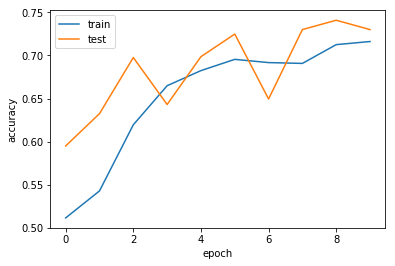

0.78942392
0.7516556


In [33]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc = 'upper left')
plt.show()

from sklearn.metrics import roc_curve, auc
y_pred_keras = model.predict(x_test).ravel()
fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, y_pred_keras)
auc_keras = auc(fpr_keras, tpr_keras)
print(auc_keras)


import tensorflow as tf
import keras.backend as K

def f1(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.cast(y_true*y_pred, 'float'), axis=0)
    # tn = K.sum(K.cast((1-y_true)*(1-y_pred), 'float'), axis=0)
    fp = K.sum(K.cast((1-y_true)*y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true*(1-y_pred), 'float'), axis=0)

    p = tp / (tp + fp + K.epsilon())
    r = tp / (tp + fn + K.epsilon())

    f1 = 2*p*r / (p+r+K.epsilon())
    f1 = tf.where(tf.is_nan(f1), tf.zeros_like(f1), f1)
    return K.mean(f1)

f1_ret = f1(y_test, y_pred_keras)
print(K.eval(f1_ret))

__Q5)__ how many weights does this network need to learn?<br>
__Q6)__ what is the AUC of this model?<br>
__Q7)__ what is the avg F1 score of this model?

In [68]:
ans['Q5'] = 15535617
ans['Q6'] = 0.78942392
ans['Q7'] = 0.7516556

3. And now for Convolutional Neural Networks.

    Here Keras needs the original 4D shape of the images array, so we `reshape` them to be of dimensions [N images X Height X Width X N channels].
    We're using a `Conv2D` layer of 32 units and a 3x3 kernel, then a 64 units layer also with a 3x3 kernel, followed by a `MaxPooling2D` with a 2xs pool size layer and a 25% `Dropout`. The output is then `Flatten`ed and connected to a `Dense` layer of 128 neurons, another 50% `Dropout` and then a single neuron with a `sigmoid` activation function.

In [49]:
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D

img_rows, img_cols, channels = 100, 100, 3

x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, channels)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, channels)
input_shape = (img_rows, img_cols, channels)

model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape = input_shape, activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

print(model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_17 (Conv2D)           (None, 98, 98, 32)        896       
_________________________________________________________________
conv2d_18 (Conv2D)           (None, 96, 96, 64)        18496     
_________________________________________________________________
max_pooling2d_9 (MaxPooling2 (None, 48, 48, 64)        0         
_________________________________________________________________
dropout_28 (Dropout)         (None, 48, 48, 64)        0         
_________________________________________________________________
flatten_8 (Flatten)          (None, 147456)            0         
_________________________________________________________________
dense_44 (Dense)             (None, 128)               18874496  
_________________________________________________________________
dropout_29 (Dropout)         (None, 128)               0         
__________

In [51]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    shuffle=True,
                    validation_data=(x_test, y_test))

score = model.evaluate(x_test, y_test, verbose=1)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 20000 samples, validate on 5000 samples
Epoch 1/10
20000/20000 [==============================] - 765s 38ms/step - loss: 0.7474 - acc: 0.6986 - val_loss: 0.4925 - val_acc: 0.7688
Epoch 2/10
20000/20000 [==============================] - 721s 36ms/step - loss: 0.4414 - acc: 0.7941 - val_loss: 0.4236 - val_acc: 0.7974
Epoch 3/10
20000/20000 [==============================] - 835s 42ms/step - loss: 0.3748 - acc: 0.8341 - val_loss: 0.4017 - val_acc: 0.8200
Epoch 4/10
20000/20000 [==============================] - 825s 41ms/step - loss: 0.3111 - acc: 0.8663 - val_loss: 0.4031 - val_acc: 0.8266
Epoch 5/10
20000/20000 [==============================] - 848s 42ms/step - loss: 0.2534 - acc: 0.8968 - val_loss: 0.3989 - val_acc: 0.8416
Epoch 6/10
20000/20000 [==============================] - 881s 44ms/step - loss: 0.1946 - acc: 0.9240 - val_loss: 0.4173 - val_acc: 0.8384
Epoch 7/10
20000/20000 [==============================] - 821s 41ms/step - loss: 0.1597 - acc: 0.9410 - val_loss: 0.4

We got a test accuracy of ~84%, which is a great improvement to what we were able to achieve before.

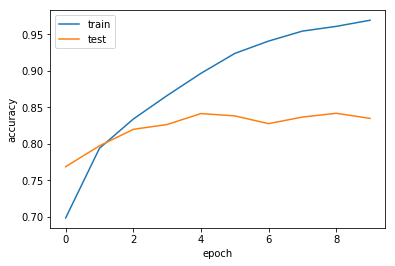

0.9075196000000001
0.83228296


In [52]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc = 'upper left')
plt.show()

from sklearn.metrics import roc_curve, auc
y_pred_keras = model.predict(x_test).ravel()
fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, y_pred_keras)
auc_keras = auc(fpr_keras, tpr_keras)
print(auc_keras)


import tensorflow as tf
import keras.backend as K

def f1(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.cast(y_true*y_pred, 'float'), axis=0)
    # tn = K.sum(K.cast((1-y_true)*(1-y_pred), 'float'), axis=0)
    fp = K.sum(K.cast((1-y_true)*y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true*(1-y_pred), 'float'), axis=0)

    p = tp / (tp + fp + K.epsilon())
    r = tp / (tp + fn + K.epsilon())

    f1 = 2*p*r / (p+r+K.epsilon())
    f1 = tf.where(tf.is_nan(f1), tf.zeros_like(f1), f1)
    return K.mean(f1)

f1_ret = f1(y_test, y_pred_keras)
print(K.eval(f1_ret))

__Q8)__ how many weights does this network need to learn?<br>
__Q9)__ what is the AUC of this model?<br>
__Q10)__ what is the avg F1 score of this model?

In [69]:
ans['Q8'] = 18894017
ans['Q9'] = 0.9075196000000001
ans['Q10'] = 0.83228296

## bonus

play with the neural network hyper-parameters (depth, # nodes, activation function, batch size, # epochs etc.)<br>
report your models AUC.<br>
you will get 5 points for beating the auc of the previous CNN model<br>
and 5 extra points for the student with the best AUC in class.<br>
__do not__ change the random seed values.<br>
 Notice you have many parameters to tune and also have a look at [`EarlyStopping`](https://keras.io/callbacks/#earlystopping) callback.

In [54]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D

img_rows, img_cols, channels = 100, 100, 3

x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, channels)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, channels)
input_shape = (img_rows, img_cols, channels)

model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape = input_shape, activation='tanh'))
model.add(Conv2D(64, (3, 3), activation='tanh'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='tanh'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

print(model.summary())

batch_size = 128
epochs = 10
model.compile(loss='binary_crossentropy',
              optimizer='SGD',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    shuffle=True,
                    validation_data=(x_test, y_test))

score = model.evaluate(x_test, y_test, verbose=1)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_19 (Conv2D)           (None, 98, 98, 32)        896       
_________________________________________________________________
conv2d_20 (Conv2D)           (None, 96, 96, 64)        18496     
_________________________________________________________________
max_pooling2d_10 (MaxPooling (None, 48, 48, 64)        0         
_________________________________________________________________
dropout_30 (Dropout)         (None, 48, 48, 64)        0         
_________________________________________________________________
flatten_9 (Flatten)          (None, 147456)            0         
_________________________________________________________________
dense_46 (Dense)             (None, 128)               18874496  
_________________________________________________________________
dropout_31 (Dropout)         (None, 128)               0         
__________

KeyboardInterrupt: 

report your best auc score<br> 
__copy your model code as string__ (we will reporoduce your settings to validate the result)

In [70]:
ans['bonus'] = 0.91091736
ans['bonus_model'] = """model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape = input_shape, activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

print(model.summary())

batch_size = 128
epochs = 8 #The only difference
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    shuffle=True,
                    validation_data=(x_test, y_test))
"""

# finish!

to submit your HW please run this last code block and follow the instructions. <BR>
this code will create a CSV file in the current directory on the azure notebooks project <br>
please download it and submit it through moodle

In [71]:
import pandas as pd
df_ans = pd.DataFrame.from_dict(ans, orient='index')
if df_ans.shape[0] == 12 or df_ans.shape[0] == 14:
    df_ans.to_csv('{}_{}.csv'.format(ans['HW'],str(ans['id_number'])))
    print("OK!")
else:
    print("seems like you missed a question, make sure you have run all the code blocks")

OK!
